# Gold and Oil Market Intelligence: Exploratory Data Analysis


In [1]:
import numpy as np
import pandas as pd
import csv

import matplotlib
matplotlib.use("Agg")

from plotnine import (
    ggplot, aes, geom_line, geom_point, geom_col, geom_histogram,
    geom_hline, geom_vline, geom_segment, geom_boxplot, geom_smooth,
    facet_wrap, scale_x_datetime, labs, theme_minimal, theme, element_text,
    coord_flip, scale_color_manual,
)

from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

## 1.Load Data

In [13]:
gold_raw = pd.read_csv("gold_stocks_price.csv")
oil_raw  = pd.read_csv("oil_price.csv")
cpi_raw  = pd.read_csv("CPIAUCSL.csv")
dxy_raw  = pd.read_csv("DTWEXBGS.csv")
vix_raw  = pd.read_csv("VIXCLS.csv")
eia_file = "SeriesExport.csv"

for name, df in [("gold", gold_raw), ("oil", oil_raw), ("cpi", cpi_raw),
                 ("dxy", dxy_raw), ("vix", vix_raw)]:
    print(f"{name:5s}: {df.shape[0]:5d} rows, {df.shape[1]} columns")

gold :  1718 rows, 81 columns
oil  :  1844 rows, 6 columns
cpi  :   953 rows, 2 columns
dxy  :  1305 rows, 2 columns
vix  :  1305 rows, 2 columns


## 2. Clean each dataset



In [14]:
def clean_gold(df):
    out = pd.DataFrame()
    out["trade_date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y", errors="coerce")
    out["close"] = pd.to_numeric(df["Close"], errors="coerce")
    out["volume"] = pd.to_numeric(df["Volume"], errors="coerce")
    out = out.dropna(subset=["trade_date", "close"])
    out = out[out["close"] > 0]
    out = out.sort_values("trade_date").drop_duplicates("trade_date", keep="last")
    return out.reset_index(drop=True)

def parse_volume(x):
    s = str(x).strip().replace(",", "")
    if s in ("", "nan", "None"):
        return np.nan
    mult = 1.0
    if s[-1:] in ("K", "k"):
        mult, s = 1e3, s[:-1]
    elif s[-1:] in ("M", "m"):
        mult, s = 1e6, s[:-1]
    elif s[-1:] in ("B", "b"):
        mult, s = 1e9, s[:-1]
    try:
        return float(s) * mult
    except ValueError:
        return np.nan

def clean_oil(df):
    out = pd.DataFrame()
    out["trade_date"] = pd.to_datetime(df["Date"], errors="coerce")
    out["close"] = pd.to_numeric(df["Price"], errors="coerce")
    out["volume"] = df["Vol."].apply(parse_volume) if "Vol." in df.columns else np.nan
    out = out.dropna(subset=["trade_date", "close"])
    out = out[out["close"] > 0]
    out = out.sort_values("trade_date").drop_duplicates("trade_date", keep="last")
    return out.reset_index(drop=True)

def clean_simple(df, value_col, out_name):
    out = pd.DataFrame()
    out["obs_date"] = pd.to_datetime(df["observation_date"], errors="coerce")
    out[out_name] = pd.to_numeric(df[value_col], errors="coerce")
    out = out.dropna(subset=["obs_date", out_name])
    out = out.sort_values("obs_date").drop_duplicates("obs_date", keep="last")
    return out.reset_index(drop=True)

gold = clean_gold(gold_raw)
oil  = clean_oil(oil_raw)
cpi  = clean_simple(cpi_raw, "CPIAUCSL", "cpi")
dxy  = clean_simple(dxy_raw, "DTWEXBGS", "dxy")
vix  = clean_simple(vix_raw, "VIXCLS", "vix")

for name, d, col in [("gold", gold, "trade_date"), ("oil", oil, "trade_date"),
                     ("cpi", cpi, "obs_date"), ("dxy", dxy, "obs_date"), ("vix", vix, "obs_date")]:
    print(f"{name:5s}: {len(d):5d} rows, {d[col].min().date()} to {d[col].max().date()}")

gold :  1718 rows, 2011-12-15 to 2018-12-31
oil  :  1844 rows, 2011-12-01 to 2018-12-31
cpi  :   952 rows, 1947-01-01 to 2026-05-01
dxy  :  1251 rows, 2021-06-07 to 2026-06-05
vix  :  1286 rows, 2021-06-10 to 2026-06-10


### Parsing the EIA world production file



In [15]:
def parse_eia_world(filename):
    rows = list(csv.reader(open(filename)))
    name_row, freq_idx = None, None
    for i, r in enumerate(rows[:10]):
        if r and r[0] == "Series Name":
            name_row = r
        if r and r[0] == "Frequency":
            freq_idx = i
    target = "Petroleum and other liquids production, World, Annual"
    col = next((j for j, v in enumerate(name_row) if v.strip() == target), None)
    years, prod = [], []
    for r in rows[freq_idx + 1:]:
        if not r or len(r) <= col:
            continue
        y = r[0].strip()
        if not y.isdigit():
            continue
        try:
            v = float(r[col].replace(",", ""))
        except ValueError:
            continue
        years.append(int(y))
        prod.append(v)
    return pd.DataFrame({"year": years, "world_mbd": prod}).sort_values("year").reset_index(drop=True)

eia = parse_eia_world(eia_file)
print(f"EIA world production: {eia['year'].min()} to {eia['year'].max()}, {len(eia)} years")
print(eia.tail(8).to_string(index=False))

EIA world production: 1980 to 2025, 35 years
 year    world_mbd
 2018 85434.135238
 2019 86897.902284
 2020 85866.651935
 2021 87383.857697
 2022 88534.047535
 2023 90802.577137
 2024 91370.215126
 2025 93947.334516


## 3. Data quality profile



In [16]:
def quality_row(name, raw_df, clean_df, date_out, val_out):
    return {
        "dataset": name,
        "raw_rows": len(raw_df),
        "clean_rows": len(clean_df),
        "dropped": len(raw_df) - len(clean_df),
        "start": clean_df[date_out].min().date(),
        "end": clean_df[date_out].max().date(),
        "missing_value_pct": round(100 * clean_df[val_out].isna().mean(), 2),
    }

quality = pd.DataFrame([
    quality_row("gold", gold_raw, gold, "trade_date", "close"),
    quality_row("oil",  oil_raw,  oil,  "trade_date", "close"),
    quality_row("cpi",  cpi_raw,  cpi,  "obs_date",   "cpi"),
    quality_row("dxy",  dxy_raw,  dxy,  "obs_date",   "dxy"),
    quality_row("vix",  vix_raw,  vix,  "obs_date",   "vix"),
])
quality

,dataset,raw_rows,clean_rows,dropped,start,end,missing_value_pct
0,gold,1718,1718,0,2011-12-15,2018-12-31,0.0
1,oil,1844,1844,0,2011-12-01,2018-12-31,0.0
2,cpi,953,952,1,1947-01-01,2026-05-01,0.0
3,dxy,1305,1251,54,2021-06-07,2026-06-05,0.0
4,vix,1305,1286,19,2021-06-10,2026-06-10,0.0


## 4. Coverage check: do the datasets overlap in time?



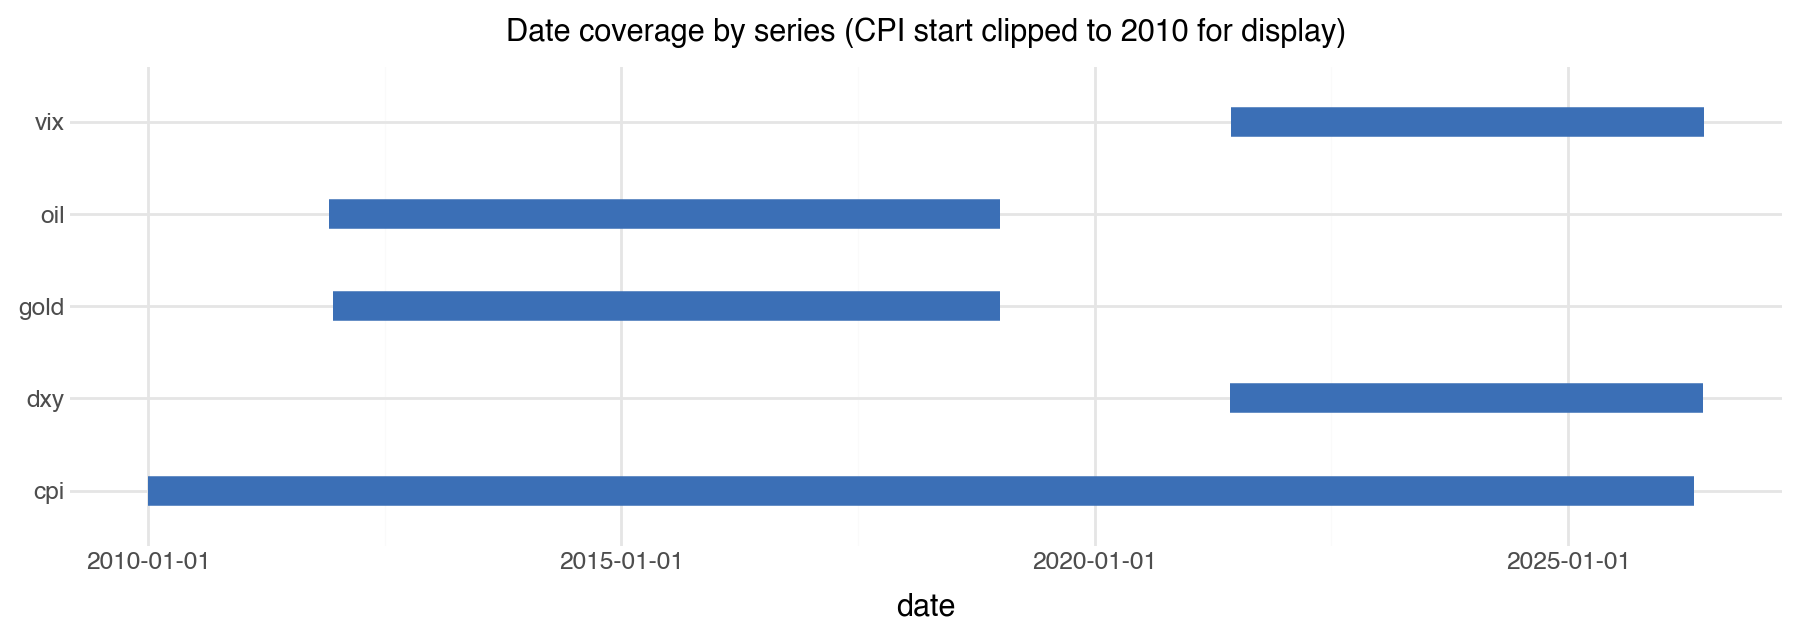

In [17]:
spans = pd.DataFrame([
    {"series": "gold", "start": gold["trade_date"].min(), "end": gold["trade_date"].max()},
    {"series": "oil",  "start": oil["trade_date"].min(),  "end": oil["trade_date"].max()},
    {"series": "cpi",  "start": cpi["obs_date"].min(),    "end": cpi["obs_date"].max()},
    {"series": "dxy",  "start": dxy["obs_date"].min(),    "end": dxy["obs_date"].max()},
    {"series": "vix",  "start": vix["obs_date"].min(),    "end": vix["obs_date"].max()},
])
disp = spans.copy()
disp.loc[disp["series"] == "cpi", "start"] = pd.Timestamp("2010-01-01")
(
    ggplot(disp, aes(y="series"))
    + geom_segment(aes(x="start", xend="end", yend="series"), size=6, color="#3b6fb6")
    + labs(title="Date coverage by series (CPI start clipped to 2010 for display)", x="date", y="")
    + theme_minimal()
    + theme(figure_size=(9, 3.2), plot_title=element_text(size=11))
)

In [18]:
def months_of(d, col):
    return set(d[col].dt.to_period("M"))

price_months = months_of(gold, "trade_date") & months_of(oil, "trade_date")
print("price (gold and oil) months:", len(price_months), min(price_months), "to", max(price_months))
print("overlap with dollar index:", len(price_months & months_of(dxy, "obs_date")), "months")
print("overlap with volatility index:", len(price_months & months_of(vix, "obs_date")), "months")

price (gold and oil) months: 85 2011-12 to 2018-12
overlap with dollar index: 0 months
overlap with volatility index: 0 months


The overlap between the price months and the dollar or volatility months is zero. The gold
versus dollar and gold versus volatility questions cannot be answered with these files, no matter
how the pipeline is written. We keep that in mind for the hypothesis section.

## 5. Monthly aggregation



In [19]:
def to_monthly(d, prefix):
    d = d.copy()
    d["month"] = d["trade_date"].dt.to_period("M").dt.to_timestamp()
    return d.groupby("month").agg(
        **{f"avg_{prefix}": ("close", "mean"),
           f"{prefix}_vol": ("close", lambda s: s.std() / s.mean()),
           f"{prefix}_volume": ("volume", "sum")}
    ).reset_index()

gm = to_monthly(gold, "gold")
om = to_monthly(oil, "oil")

cm = cpi.copy()
cm["month"] = cm["obs_date"].dt.to_period("M").dt.to_timestamp()
cm = cm.groupby("month")["cpi"].last().reset_index()

monthly = gm.merge(om, on="month", how="inner").merge(cm, on="month", how="left")
monthly = monthly.sort_values("month").reset_index(drop=True)
monthly["gold_ret"] = monthly["avg_gold"].pct_change() * 100
monthly["oil_ret"]  = monthly["avg_oil"].pct_change() * 100
monthly["infl_yoy"] = (monthly["cpi"] / monthly["cpi"].shift(12) - 1) * 100
monthly["corr_go_12m"] = monthly["avg_gold"].rolling(12).corr(monthly["avg_oil"])

print("monthly rows:", len(monthly), "from", monthly["month"].min().date(), "to", monthly["month"].max().date())
monthly.head()

monthly rows: 85 from 2011-12-01 to 2018-12-01


,month,avg_gold,gold_vol,gold_volume,avg_oil,oil_vol,oil_volume,cpi,gold_ret,oil_ret,infl_yoy,corr_go_12m
0,2011-12-01,154.289999,0.015820,138798900,98.575714,0.025384,4698820.0,227.223,NaN,NaN,NaN,NaN
1,2012-01-01,161.334211,0.026002,204310100,100.318500,0.014803,5408830.0,227.842,4.565566,1.767967,NaN,NaN
2,2012-02-01,169.278500,0.014808,259837600,102.262500,0.042191,5538670.0,228.329,4.924119,1.937828,NaN,NaN
3,2012-03-01,162.795001,0.014085,272582900,106.205000,0.013747,5736270.0,228.807,-3.830078,3.855274,NaN,NaN
4,2012-04-01,160.235501,0.008853,198905400,103.346000,0.010888,4480320.0,229.187,-1.572223,-2.691964,NaN,NaN


## 6. Exploratory charts

### Price trends over the period

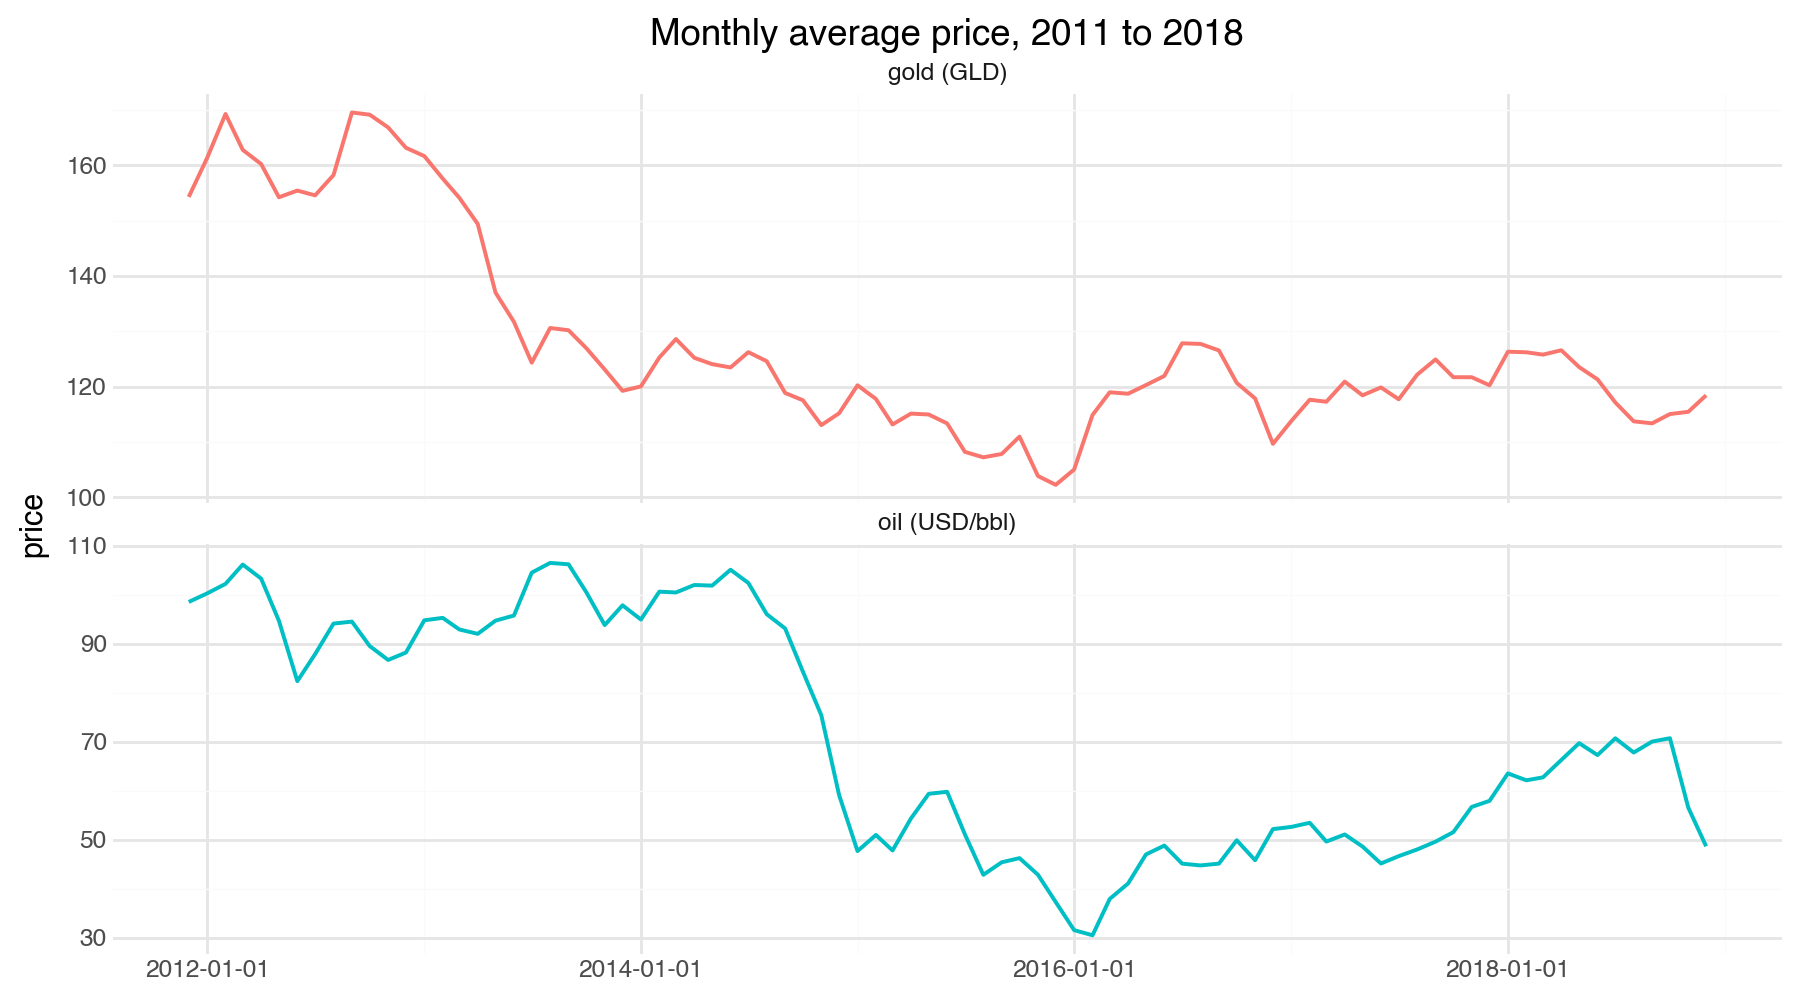

In [20]:
price_long = pd.concat([
    monthly[["month", "avg_gold"]].rename(columns={"avg_gold": "value"}).assign(series="gold (GLD)"),
    monthly[["month", "avg_oil"]].rename(columns={"avg_oil": "value"}).assign(series="oil (USD/bbl)"),
])
(
    ggplot(price_long, aes("month", "value", color="series"))
    + geom_line(size=0.8)
    + facet_wrap("series", scales="free_y", ncol=1)
    + labs(title="Monthly average price, 2011 to 2018", x="", y="price")
    + theme_minimal()
    + theme(figure_size=(9, 5), legend_position="none")
)

### Distribution of monthly returns

Oil returns sit on a wider spread than gold returns, the first sign that oil is more volatile.

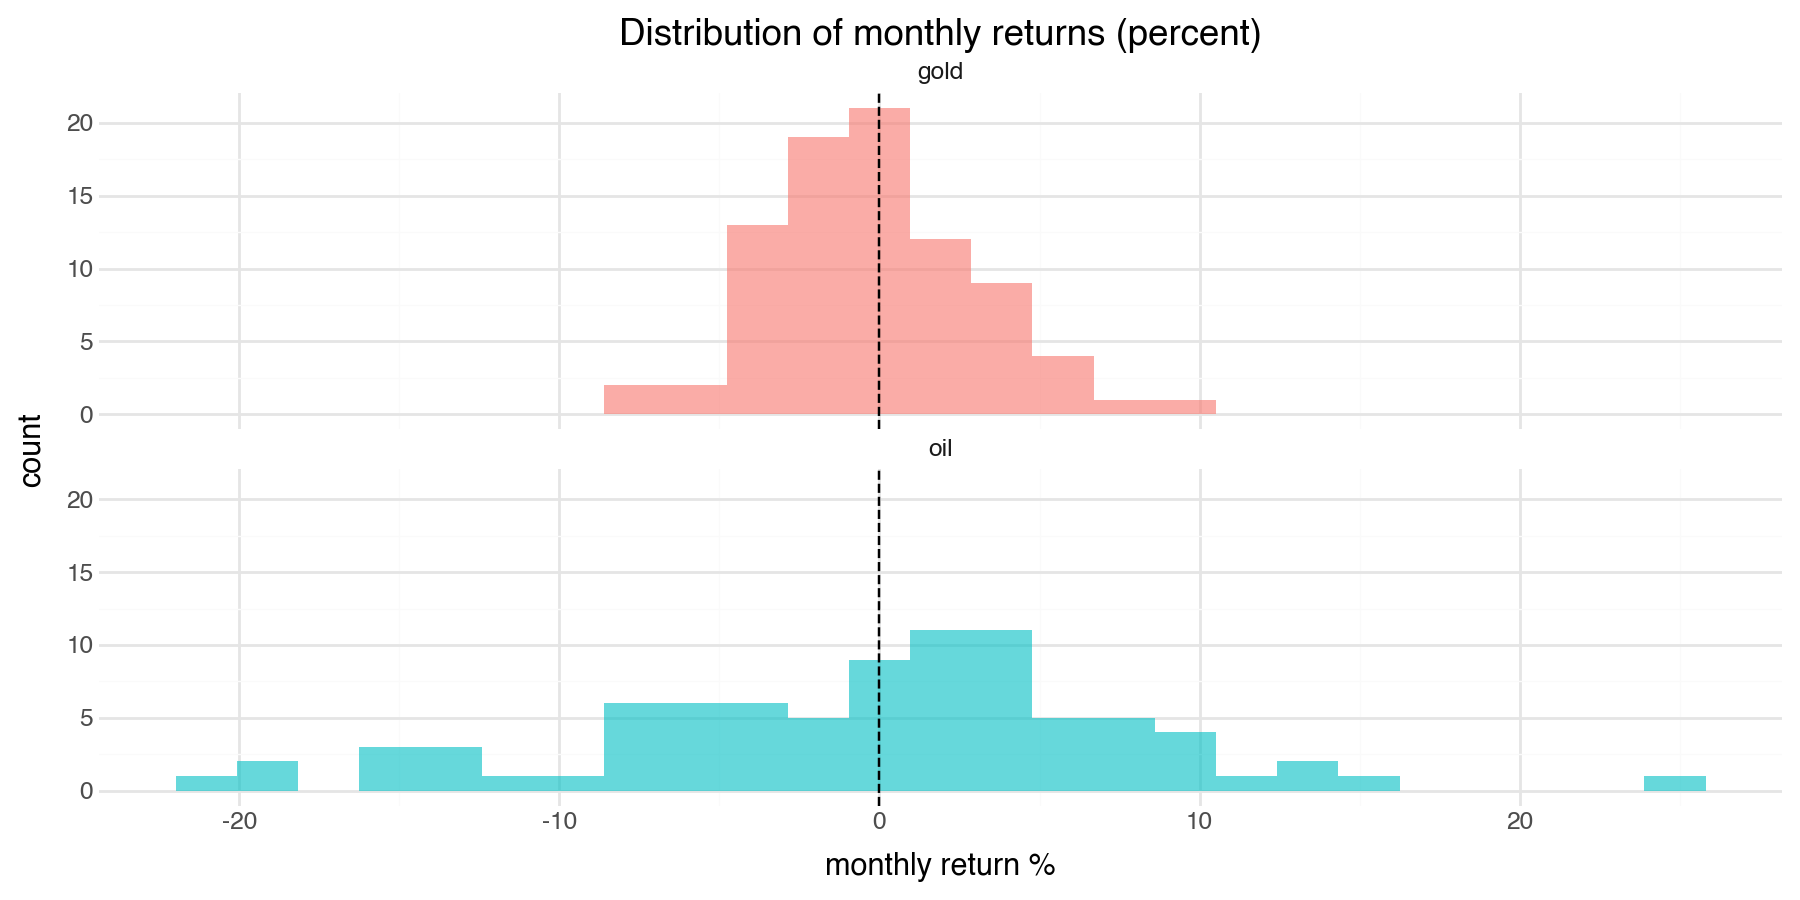

In [21]:
ret_long = pd.concat([
    monthly[["gold_ret"]].rename(columns={"gold_ret": "ret"}).assign(series="gold"),
    monthly[["oil_ret"]].rename(columns={"oil_ret": "ret"}).assign(series="oil"),
]).dropna()
(
    ggplot(ret_long, aes("ret", fill="series"))
    + geom_histogram(bins=25, alpha=0.6, position="identity")
    + geom_vline(xintercept=0, linetype="dashed")
    + facet_wrap("series", ncol=1)
    + labs(title="Distribution of monthly returns (percent)", x="monthly return %", y="count")
    + theme_minimal()
    + theme(figure_size=(9, 4.5), legend_position="none")
)

### Within month volatility, gold versus oil

mean within month volatility:
series
gold    0.0157
oil     0.0327
Name: vol, dtype: float64


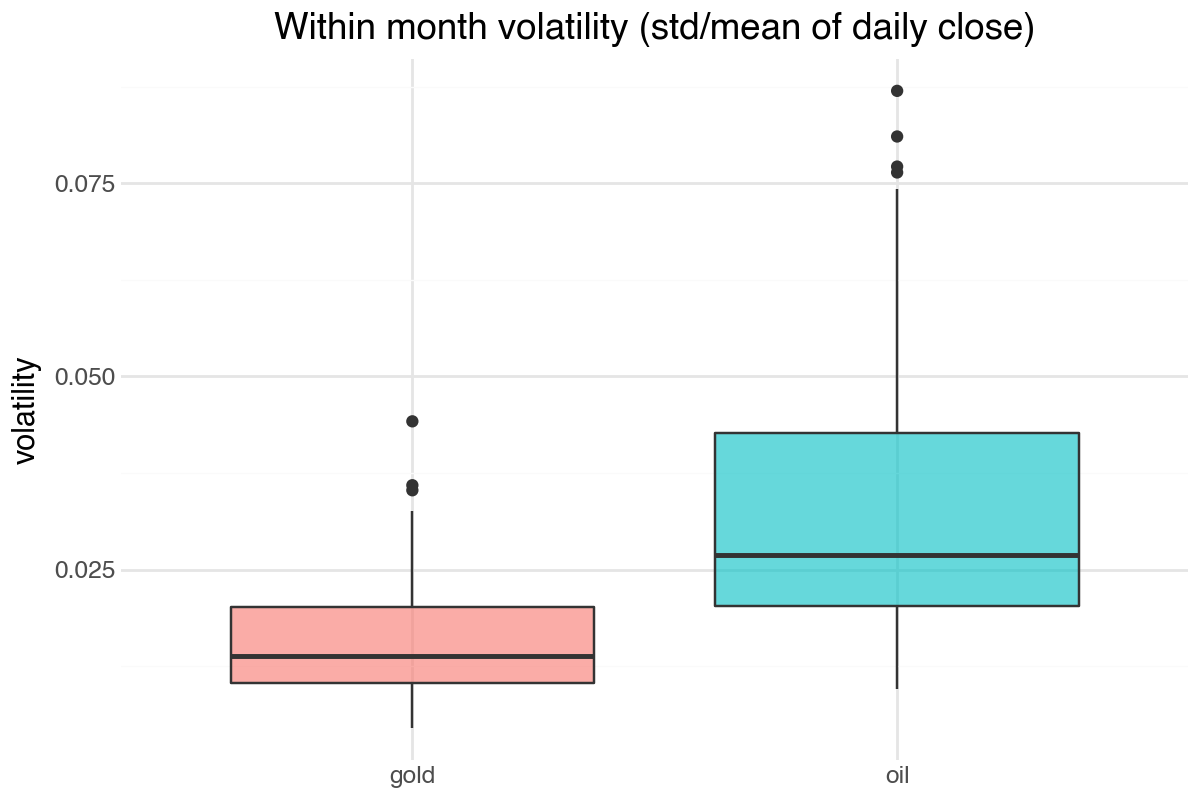

In [22]:
vol_long = pd.concat([
    monthly[["month", "gold_vol"]].rename(columns={"gold_vol": "vol"}).assign(series="gold"),
    monthly[["month", "oil_vol"]].rename(columns={"oil_vol": "vol"}).assign(series="oil"),
]).dropna()
print("mean within month volatility:")
print(vol_long.groupby("series")["vol"].mean().round(4))
(
    ggplot(vol_long, aes("series", "vol", fill="series"))
    + geom_boxplot(alpha=0.6)
    + labs(title="Within month volatility (std/mean of daily close)", x="", y="volatility")
    + theme_minimal()
    + theme(figure_size=(6, 4), legend_position="none")
)

### Rolling 12 month correlation between gold and oil

The relationship is not stable. It moves between strong positive and strong negative, which is
why a single correlation number is misleading.

rolling gold-oil correlation: mean 0.120, min -0.847, max 0.857
level correlation 0.635, return correlation 0.011


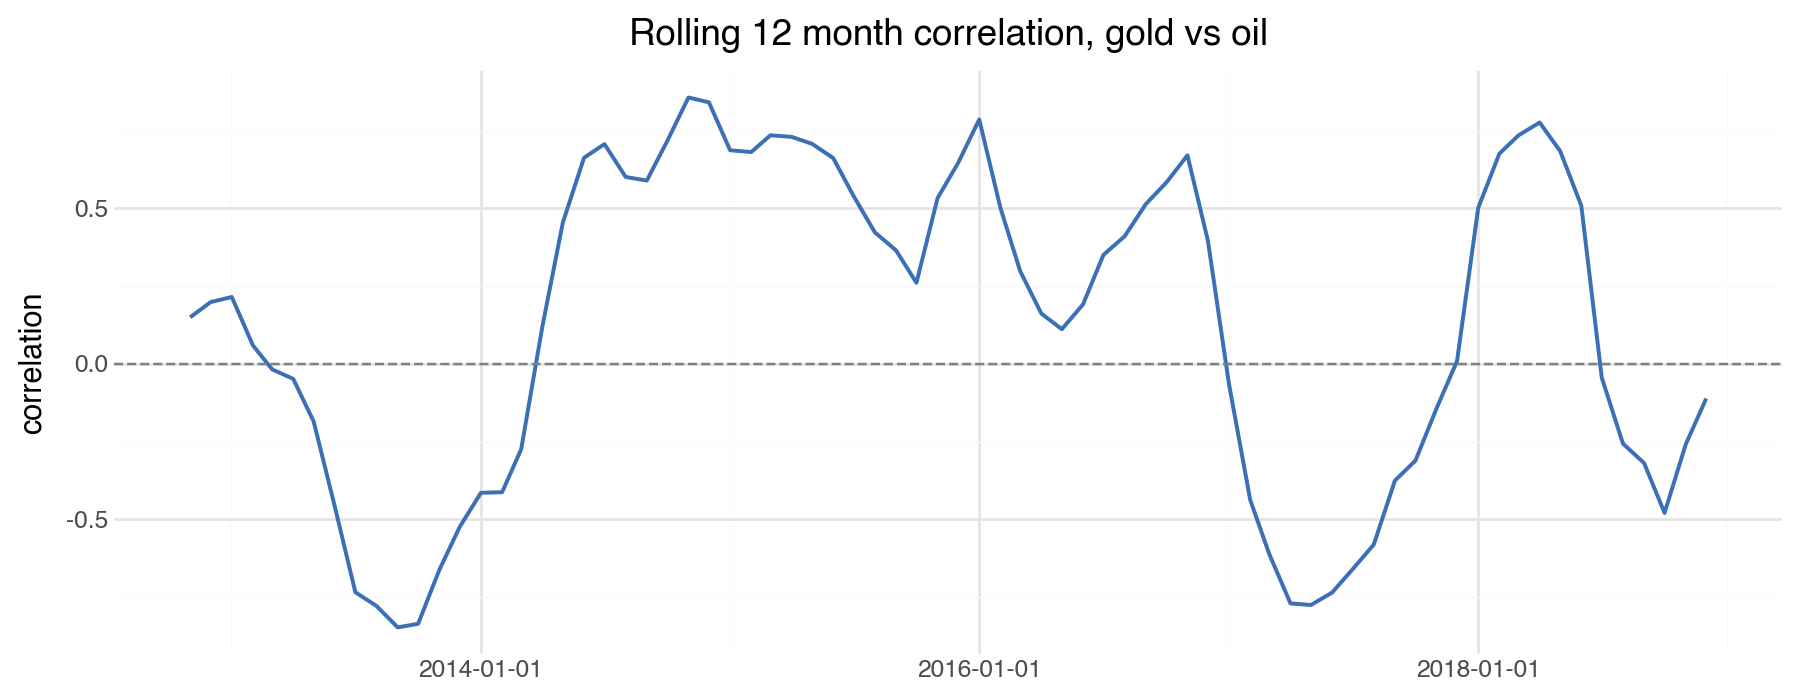

In [23]:
corr_df = monthly.dropna(subset=["corr_go_12m"])
print("rolling gold-oil correlation: mean %.3f, min %.3f, max %.3f"
      % (corr_df["corr_go_12m"].mean(), corr_df["corr_go_12m"].min(), corr_df["corr_go_12m"].max()))
print("level correlation %.3f, return correlation %.3f"
      % (monthly["avg_gold"].corr(monthly["avg_oil"]),
         monthly["gold_ret"].corr(monthly["oil_ret"])))
(
    ggplot(corr_df, aes("month", "corr_go_12m"))
    + geom_line(size=0.8, color="#3b6fb6")
    + geom_hline(yintercept=0, linetype="dashed", color="grey")
    + labs(title="Rolling 12 month correlation, gold vs oil", x="", y="correlation")
    + theme_minimal()
    + theme(figure_size=(9, 3.5))
)

### Inflation versus gold return

Each point is a month. If gold were a clear inflation hedge in this period, higher inflation
months would sit higher on the return axis. The fitted line shows the opposite tilt, which we
test formally later.

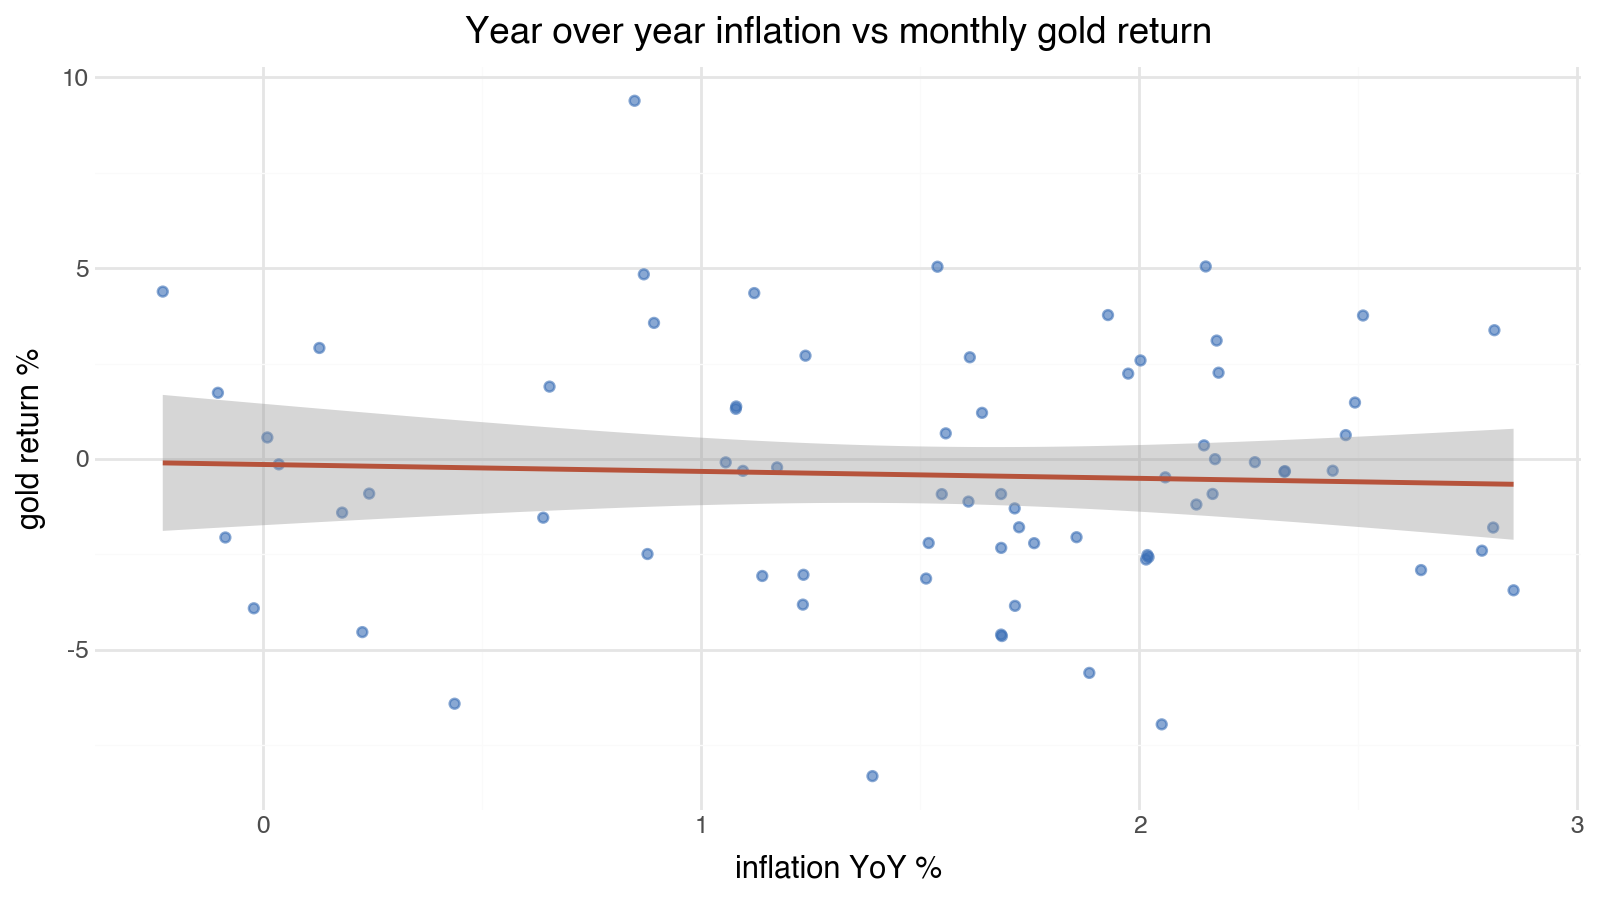

In [24]:
sc = monthly.dropna(subset=["infl_yoy", "gold_ret"])
(
    ggplot(sc, aes("infl_yoy", "gold_ret"))
    + geom_point(alpha=0.6, color="#3b6fb6")
    + geom_smooth(method="lm", color="#b6533b", se=True)
    + labs(title="Year over year inflation vs monthly gold return", x="inflation YoY %", y="gold return %")
    + theme_minimal()
    + theme(figure_size=(8, 4.5))
)

## 7. Preprocessing and unsupervised grouping with scikit-learn



In [25]:
features = ["gold_ret", "oil_ret", "gold_vol", "oil_vol", "infl_yoy"]
feat = monthly.dropna(subset=["gold_ret", "oil_ret"]).copy()
X = feat[features].values

prep = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
Xz = prep.fit_transform(X)

km = KMeans(n_clusters=3, n_init=10, random_state=42)
feat["cluster"] = km.fit_predict(Xz).astype(str)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(Xz)
feat["pc1"], feat["pc2"] = coords[:, 0], coords[:, 1]

print("feature columns used:", features)
print("explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_, 3))
print("\ncluster profile (means in original units):")
print(feat.groupby("cluster")[features].mean().round(2))

feature columns used: ['gold_ret', 'oil_ret', 'gold_vol', 'oil_vol', 'infl_yoy']
explained variance ratio (PC1, PC2): [0.34  0.228]

cluster profile (means in original units):
         gold_ret  oil_ret  gold_vol  oil_vol  infl_yoy
cluster                                                
0           -0.01   -10.54      0.02     0.06      0.88
1           -0.70     1.03      0.01     0.03      2.10
2            0.27     3.66      0.02     0.03      1.03


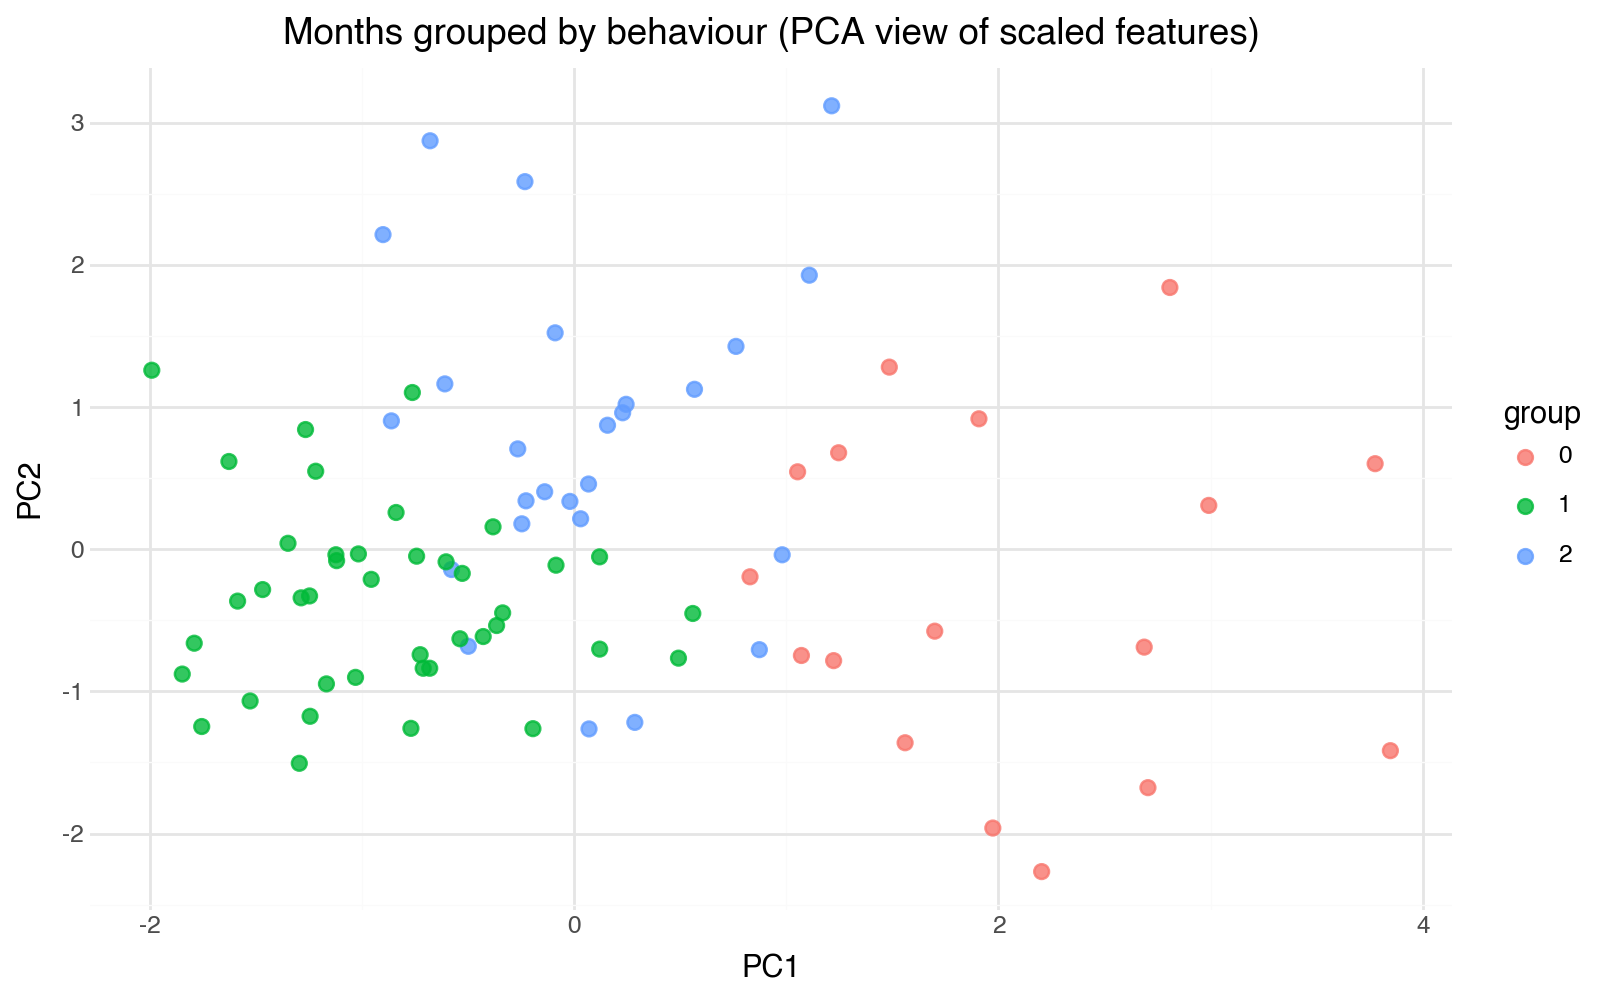

In [26]:
(
    ggplot(feat, aes("pc1", "pc2", color="cluster"))
    + geom_point(size=2.5, alpha=0.8)
    + labs(title="Months grouped by behaviour (PCA view of scaled features)",
           x="PC1", y="PC2", color="group")
    + theme_minimal()
    + theme(figure_size=(8, 5))
)

## 8. Hypothesis tests on the data that supports them

We recompute the tests in the notebook so the numbers are visible and reproducible.

### H2: gold returns in high versus low inflation months (Welch t-test)

In [27]:
b = monthly.dropna(subset=["infl_yoy", "gold_ret"]).copy()
thr = b["infl_yoy"].mean()
hi = b.loc[b["infl_yoy"] >= thr, "gold_ret"]
lo = b.loc[b["infl_yoy"] < thr, "gold_ret"]
t, p = stats.ttest_ind(hi, lo, equal_var=False)
print(f"threshold (mean YoY inflation): {thr:.2f}%")
print(f"high inflation months: n={len(hi)}, mean gold return {hi.mean():.3f}%")
print(f"low inflation months:  n={len(lo)}, mean gold return {lo.mean():.3f}%")
print(f"effect {hi.mean()-lo.mean():.3f} pp, t={t:.3f}, p={p:.4f}")
print("verdict:", "reject H0 at 95%" if p < 0.05 else "fail to reject H0 (not significant)")

threshold (mean YoY inflation): 1.51%
high inflation months: n=45, mean gold return -0.608%
low inflation months:  n=28, mean gold return -0.115%
effect -0.493 pp, t=-0.598, p=0.5526
verdict: fail to reject H0 (not significant)


### H3: annual oil returns when world output falls versus rises

This test needs the EIA annual series joined to annual oil prices. The overlap has only one year
of falling world output, so a two group comparison is not defined.

In [28]:
oa = oil.copy()
oa["year"] = oa["trade_date"].dt.year
oa = oa.groupby("year")["close"].mean().reset_index().rename(columns={"close": "avg_oil"})
j = oa.merge(eia, on="year", how="inner").sort_values("year")
j["oil_ret_yoy"] = j["avg_oil"].pct_change() * 100
j["prod_chg"] = j["world_mbd"].diff()
print(j[["year", "avg_oil", "world_mbd", "oil_ret_yoy", "prod_chg"]].to_string(index=False))
bb = j.dropna(subset=["prod_chg", "oil_ret_yoy"])
bb = bb[bb["prod_chg"] != 0]
cut = bb.loc[bb["prod_chg"] < 0, "oil_ret_yoy"]
inc = bb.loc[bb["prod_chg"] >= 0, "oil_ret_yoy"]
print(f"\nfalling output years: n={len(cut)}; rising output years: n={len(inc)}")
if len(cut) >= 2 and len(inc) >= 2:
    t, p = stats.ttest_ind(cut, inc, equal_var=False)
    print(f"effect {cut.mean()-inc.mean():.2f} pp, t={t:.3f}, p={p:.4f}")
else:
    print("test not defined: one group has fewer than two observations")

 year   avg_oil    world_mbd  oil_ret_yoy    prod_chg
 2011 98.575714 75621.902904          NaN         NaN
 2012 94.145238 75764.241877    -4.494491  142.338973
 2013 98.054883 75599.861893     4.152780 -164.379984
 2014 92.823308 79071.851077    -5.335354 3471.989184
 2015 48.879394 83435.740404   -47.341465 4363.889328
 2016 43.410076 84702.433816   -11.189415 1266.693412
 2017 50.911293 85225.204441    17.279898  522.770625
 2018 64.825038 85434.135238    27.329389  208.930797

falling output years: n=1; rising output years: n=6
test not defined: one group has fewer than two observations


### Gold and oil return relationship (correlation significance)

In [29]:
d = monthly.dropna(subset=["gold_ret", "oil_ret"])
r, p = stats.pearsonr(d["gold_ret"], d["oil_ret"])
print(f"gold vs oil monthly return correlation r={r:.3f}, p={p:.4f}, n={len(d)}")
print("verdict:", "linked" if p < 0.05 else "no significant linear link in monthly returns")
lr = LinearRegression().fit(d[["oil_ret"]].values, d["gold_ret"].values)
print(f"slope of gold_ret on oil_ret: {lr.coef_[0]:.4f}")

gold vs oil monthly return correlation r=0.011, p=0.9210, n=84
verdict: no significant linear link in monthly returns
slope of gold_ret on oil_ret: 0.0044


## 9. Summary of findings

* The supplied window for prices is December 2011 to December 2018, 85 months. Over it, gold
  fell about 23 percent and oil about 51 percent. This was a commodity bear market, not a safe
  haven period.
* Oil was roughly twice as volatile as gold month to month.
* Gold and oil correlate strongly on price levels (about 0.64) but almost not at all on monthly
  returns (about 0.01). The rolling correlation swings between strong positive and strong
  negative, so the relationship is regime dependent and should be reported on a rolling basis.
* The inflation hedge claim does not hold in this window. Gold did slightly worse in higher
  inflation months and the difference is not significant (p about 0.55).
* The oil supply test is not defined here because world output rose in all but one year of the
  overlap.
* The dollar and volatility questions cannot be answered with these files. The price series and
  the dollar and volatility series do not share a single month. A pipeline that joins them would
  return empty results without raising an error, which is why the coverage check matters.

The practical next step is to align the data in time: obtain gold and oil prices for 2021 to 2026
to match the dollar and volatility series, or obtain those macro series back to 2011. Until then
the cross asset questions stay open and should be labelled as such.